In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Customer_Churn_Thesis/'
os.chdir(project_path)
print("Project path:", project_path)

Mounted at /content/drive
Project path: /content/drive/MyDrive/Customer_Churn_Thesis/


In [2]:
DATA_PATH = os.path.join(project_path, "data/processed")
RESULTS_PATH = os.path.join(project_path, "results")

os.makedirs(f"{RESULTS_PATH}/figures", exist_ok=True)
os.makedirs(f"{RESULTS_PATH}/tables", exist_ok=True)

print(project_path)

/content/drive/MyDrive/Customer_Churn_Thesis/


In [3]:
!pip install shap lightgbm xgboost

In [4]:
import pandas as pd
import numpy as np

import shap
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier

from sklearn.metrics import recall_score, f1_score

In [5]:
train = pd.read_csv(f"{DATA_PATH}/train_augmented.csv")
test = pd.read_csv(f"{DATA_PATH}/test_original.csv")

train.head()
test.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Balance_Per_Product,Tenure_Age_Ratio,Is_Senior,Geography_Germany,Geography_Spain,Gender_Male,Exited
0,585,36,7,0.00,2,1,0,94283.09,0.000,0.194444,0,False,False,True,0
1,525,33,4,131023.76,2,0,0,55072.93,65511.880,0.121212,0,True,False,True,0
2,557,40,4,0.00,2,0,1,105433.53,0.000,0.100000,0,False,True,False,0
3,639,34,5,139393.19,2,0,0,33950.08,69696.595,0.147059,0,False,True,True,0
4,640,34,3,77826.80,1,1,1,168544.85,77826.800,0.088235,0,False,True,False,0


In [6]:
TARGET = "Exited"

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

print(X_train.shape)

(12740, 14)


In [7]:
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 6370, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 12740, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

LGBMClassifier(learning_rate=0.05, max_depth=6, n_estimators=300,
               random_state=42)

In [8]:
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:,1]

precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)
roc = roc_auc_score(y_test, probs)
accuracy = accuracy_score(y_test, preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc)

Accuracy: 0.84
Precision: 0.6028368794326241
Recall: 0.6265356265356266
F1: 0.6144578313253012
ROC-AUC: 0.8445980649370479


In [9]:
results = pd.DataFrame({
    "Recall":[recall],
    "F1":[f1],
    "Precision":[precision],
    "ROC-AUC":[roc],
    "Accuracy":[accuracy]
})
print(results)
results.to_csv(
    f"{RESULTS_PATH}/tables/04_SHAP_Explainability_Phase2_SHAP_results.csv",
    index=False
)

print("Results saved to Drive")

     Recall        F1  Precision   ROC-AUC  Accuracy
0  0.626536  0.614458   0.602837  0.844598      0.84
Results saved to Drive


In [10]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]


print(shap_values.shape)

(2000, 14)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


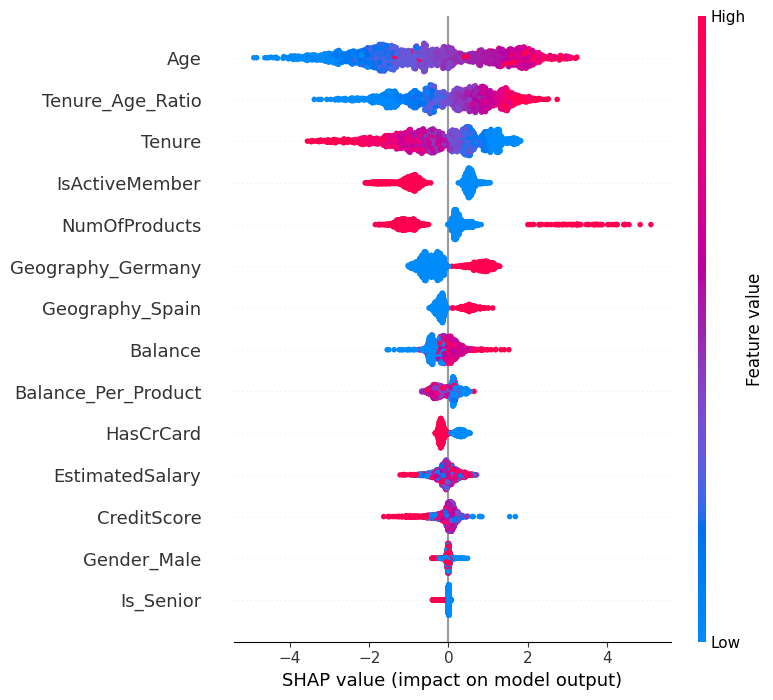

In [11]:
shap.summary_plot(shap_values, X_test,show=False)

fig = plt.gcf()

fig.savefig(
    f"{RESULTS_PATH}/figures/04_SHAP_Explainability_Phase2_shap_summary_plot.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()
plt.close(fig)


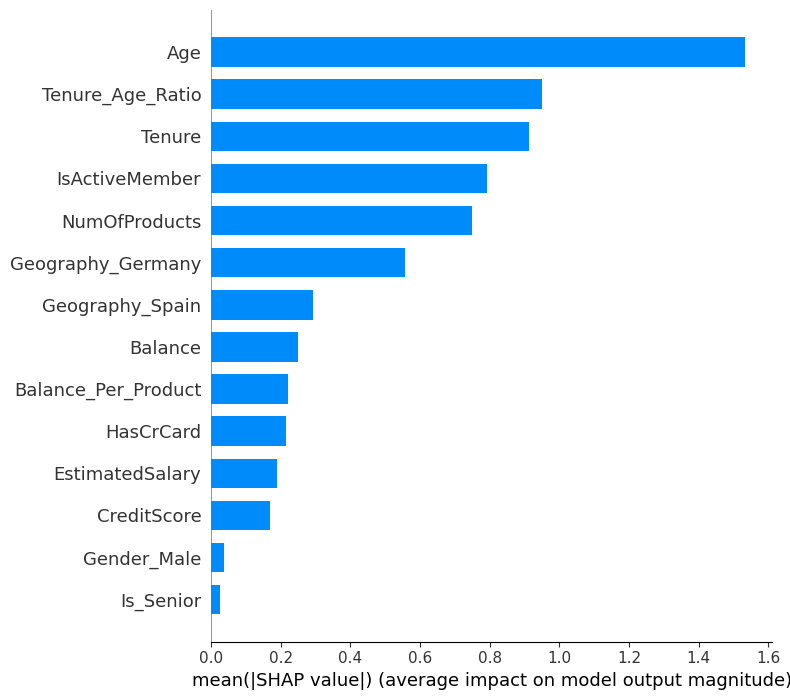

In [12]:
shap.summary_plot(shap_values, X_test, plot_type="bar",show=False)

fig = plt.gcf()

fig.savefig(
    f"{RESULTS_PATH}/figures/04_SHAP_Explainability_Phase2_shap_feature_importance.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()
plt.close(fig)

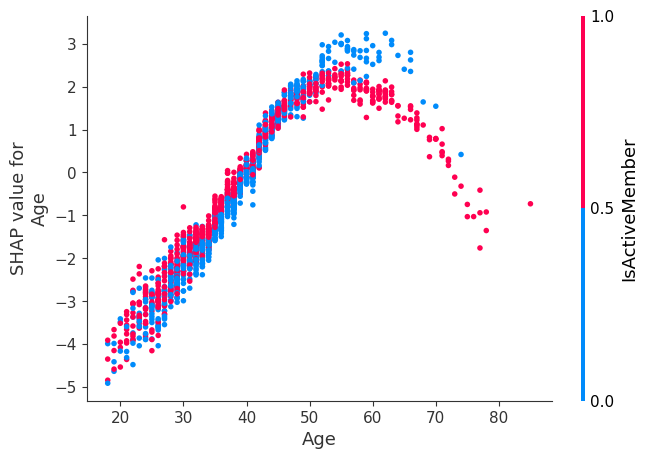

In [13]:
shap.dependence_plot("Age", shap_values, X_test,show=False)

fig = plt.gcf()

fig.savefig(
    f"{RESULTS_PATH}/figures/04_SHAP_Explainability_Phase2_shap_dependence_age.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()
plt.close(fig)

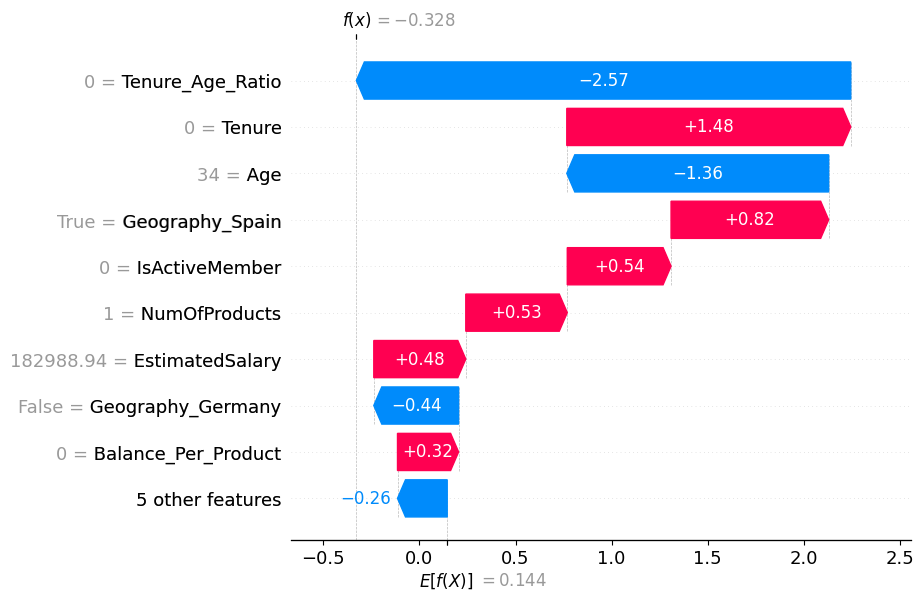

In [14]:
index = 5

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[index],
        base_values=explainer.expected_value,
        data=X_test.iloc[index],
        feature_names=X_test.columns
    ),show=False
)

fig = plt.gcf()

fig.savefig(
    f"{RESULTS_PATH}/figures/04_SHAP_Explainability_Phase2_shap_waterfall_index_5.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()
plt.close(fig)

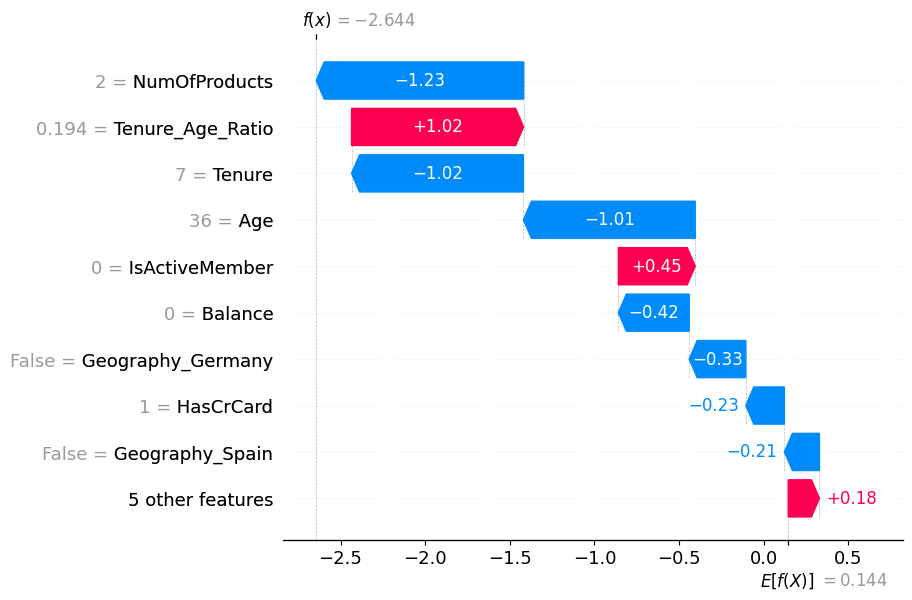

In [15]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    ),show=False
)

fig = plt.gcf()

fig.savefig(
    f"{RESULTS_PATH}/figures/04_SHAP_Explainability_Phase2_shap_waterfall_index_0.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()
plt.close(fig)

In [16]:
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
print(shap_df)
shap_df.to_csv(
    f"{RESULTS_PATH}/tables/04_SHAP_Explainability_Phase2_shap_values.csv",
    index=False
)

print("SHAP values saved")

      CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
0        0.069171 -1.014894 -1.015326 -0.418680      -1.225188  -0.227956   
1        0.042645 -1.926675  0.297439  0.279491      -0.931746   0.394904   
2       -0.024093  0.050842  0.039928 -0.505589      -1.123499   0.354721   
3        0.081715 -1.702639 -0.240191  0.217430      -0.908419   0.408322   
4        0.066483 -1.274722  0.555707  0.018899       0.234040  -0.228417   
...           ...       ...       ...       ...            ...        ...   
1995    -0.079627 -0.695983  0.862697  0.151559       0.184006   0.310655   
1996     0.280962 -0.550660  0.479949  0.302723      -0.777493  -0.189943   
1997     0.045215  2.017559 -1.925487  0.036615       0.199068   0.302823   
1998     0.065206 -0.072022 -0.967592 -0.421475      -1.303474   0.370658   
1999    -0.056723 -1.617909  0.922403 -0.060700       0.331812  -0.105057   

      IsActiveMember  EstimatedSalary  Balance_Per_Product  Tenure_Age_Rati